![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/tutorials/Certification_Trainings/01.01.Image_processing.ipynb)

If you are using the `johnsnowlabs` library, please use this [01.01.Image_processing](https://github.com/JohnSnowLabs/visual-nlp-workshop/blob/master/tutorials/Certification_Trainings_JSL/01.01.Image_processing.ipynb) notebook.

## Blogposts and videos

- [Text Detection in Spark OCR](https://medium.com/spark-nlp/text-detection-in-spark-ocr-dcd8002bdc97)

- [Table Detection & Extraction in Spark OCR](https://medium.com/spark-nlp/table-detection-extraction-in-spark-ocr-50765c6cedc9)

- [Extract Tabular Data from PDF in Spark OCR](https://medium.com/spark-nlp/extract-tabular-data-from-pdf-in-spark-ocr-b02136bc0fcb)

- [Signature Detection in Spark OCR](https://medium.com/spark-nlp/signature-detection-in-spark-ocr-32f9e6f91e3c)

- [GPU image pre-processing in Spark OCR](https://medium.com/spark-nlp/gpu-image-pre-processing-in-spark-ocr-3-1-0-6fc27560a9bb)

- [How to Setup Spark OCR on UBUNTU - Video](https://www.youtube.com/watch?v=cmt4WIcL0nI)


**More examples here**

https://github.com/JohnSnowLabs/spark-ocr-workshop

In [ ]:
# NBVAL_SKIP
import json, os
import sys

if 'google.colab' in sys.modules:
    from google.colab import files

    if 'spark_ocr.json' not in os.listdir():
      license_keys = files.upload()
      os.rename(list(license_keys.keys())[0], 'spark_ocr.json')

with open('spark_ocr.json') as f:
    license_keys = json.load(f)

# Defining license key-value pairs as local variables
locals().update(license_keys)

In [ ]:
# NBVAL_SKIP
# Installing pyspark and spark-nlp
%pip install --upgrade -q pyspark==3.4.1 spark-nlp==$PUBLIC_VERSION

# Installing Spark OCR
#! pip uninstall spark-ocr -Y
%pip install spark-ocr==$OCR_VERSION --extra-index-url=https://pypi.johnsnowlabs.com/$SPARK_OCR_SECRET --upgrade

<b><h1><font color='darkred'>!!! ATTENTION !!! </font><h1><b>

<b>Running the next cell will <font color='darkred'>automatically restart the Colab runtime</font>. This is expected — once it restarts, just continue running the cells below.<b>

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
# NBVAL_SKIP
import json, os

with open("spark_ocr.json", 'r') as f:
  license_keys = json.load(f)

# Adding license key-value pairs to environment variables
os.environ.update(license_keys)

# Defining license key-value pairs as local variables
locals().update(license_keys)

In [2]:
import importlib.resources

from pyspark.ml import PipelineModel
from pyspark.sql import functions as F

from sparkocr import start
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *
from sparkocr.metrics import score

In [3]:
# Start spark
spark = start(secret=SPARK_OCR_SECRET)

Spark version: 3.4.1
Spark NLP version: 6.4.0
Spark OCR version: 6.4.0



## Read image


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 582 px
    Height: 744 px
    Mode: 10
    Number of channels: 1


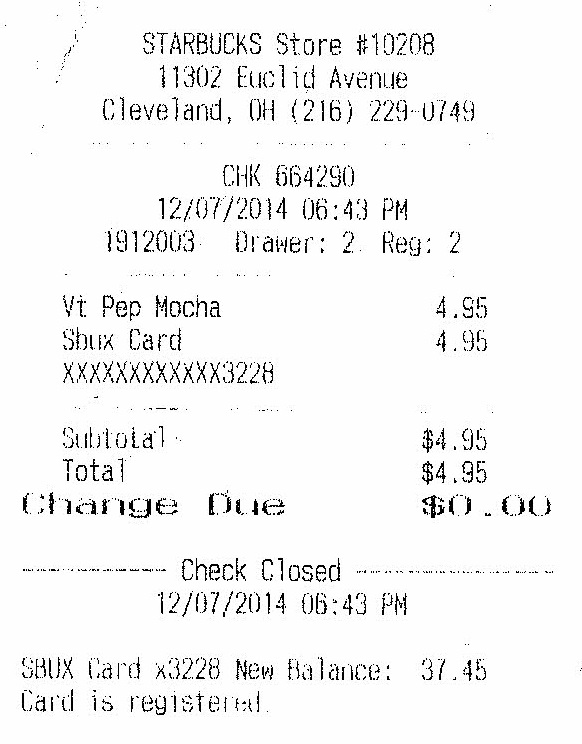

In [4]:
image_path = str(importlib.resources.files('sparkocr') / 'resources/ocr/images/check.jpg')
image_example_df = spark.read.format("binaryFile").load(image_path)
image_df = BinaryToImage().transform(image_example_df).cache()

display_images(image_df)

## Scaling


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 1164 px
    Height: 1488 px
    Mode: 10
    Number of channels: 1


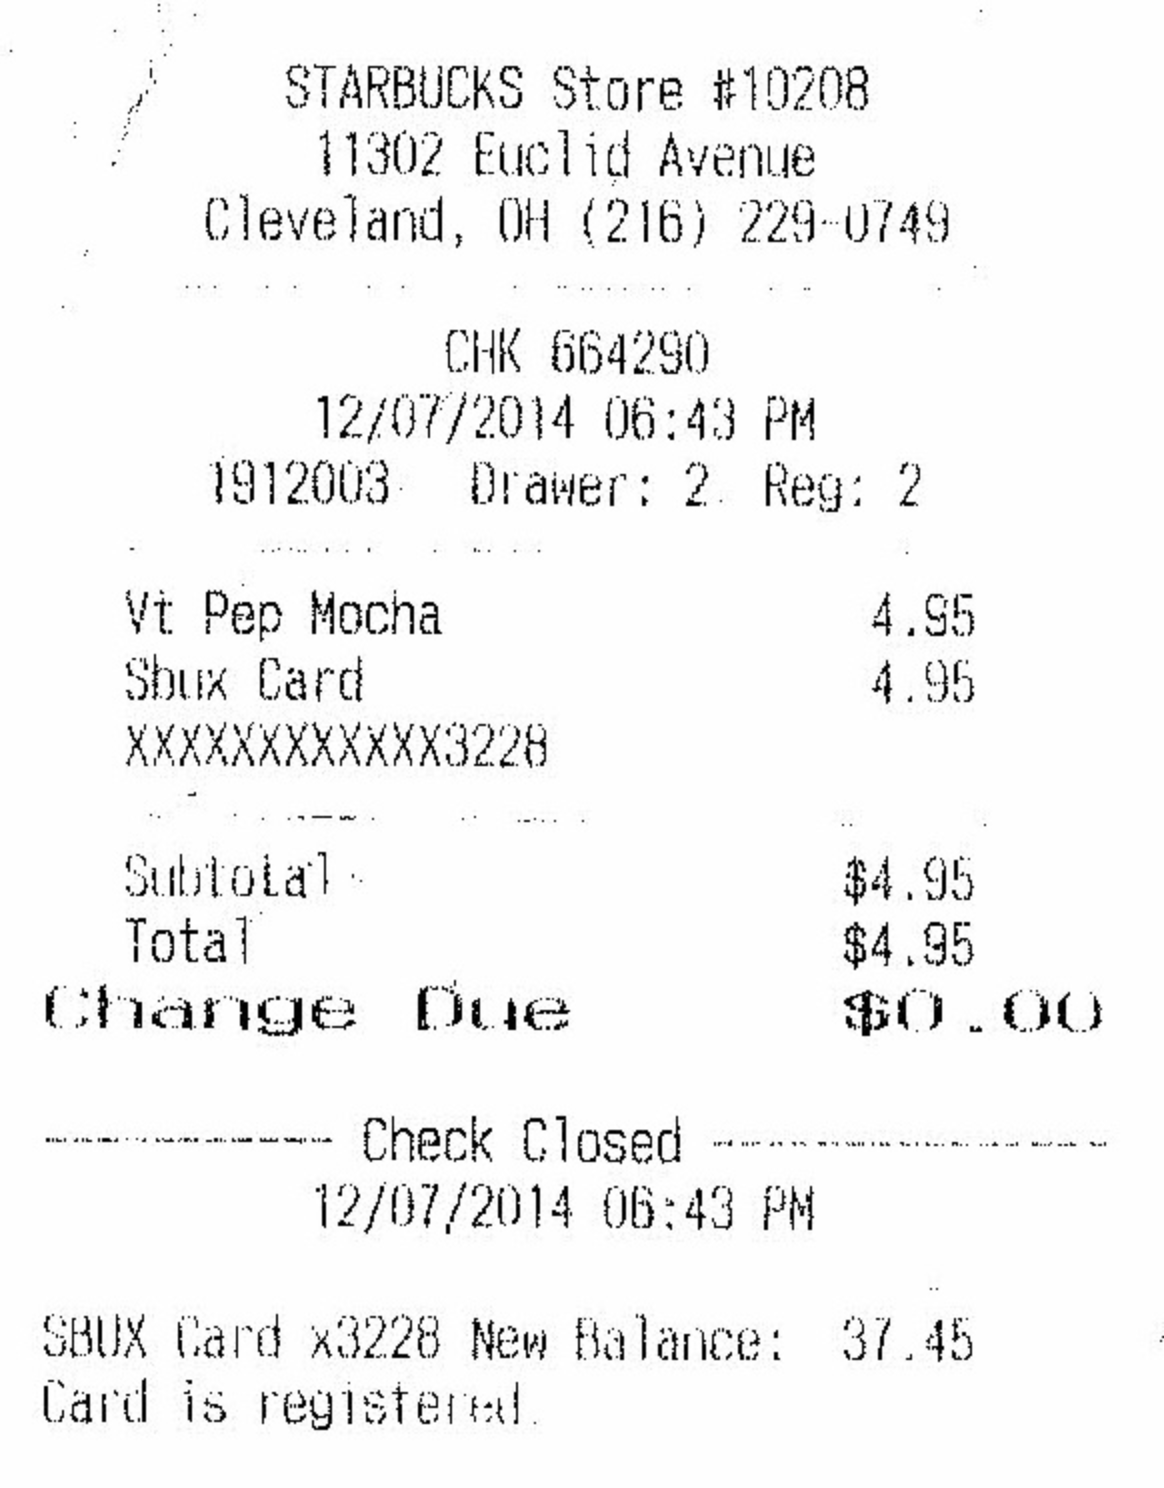

In [5]:
scaled_image_df = ImageTransformer() \
    .addScalingTransform(2) \
    .setInputCol("image") \
    .setOutputCol("scaled_image") \
    .setImageType(ImageType.TYPE_BYTE_GRAY) \
    .transform(image_df)

display_images(scaled_image_df, "scaled_image")

## Image Adaptive Thresholding


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 582 px
    Height: 744 px
    Mode: 12
    Number of channels: 3


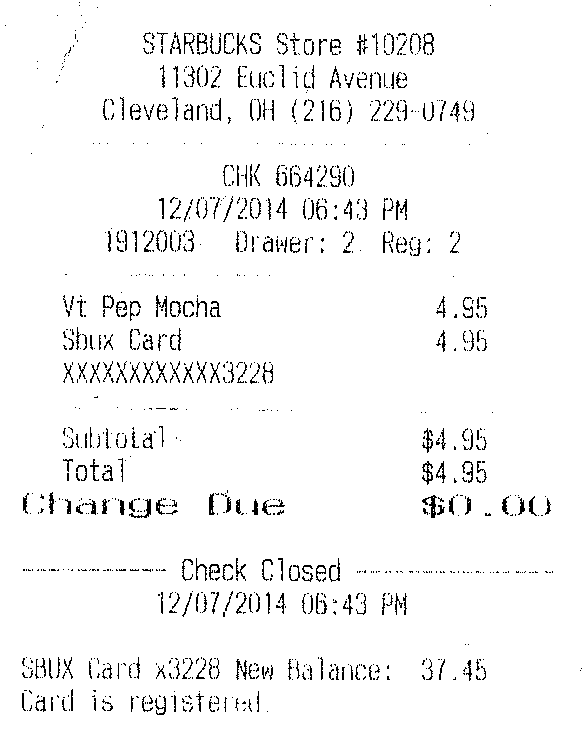

In [6]:
thresholded_image = ImageTransformer() \
    .addAdaptiveThreshold(21, 20)\
    .setInputCol("image") \
    .setOutputCol("thresholded_image") \
    .transform(image_df)

display_images(thresholded_image, "thresholded_image")

## Erosion


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 582 px
    Height: 744 px
    Mode: 12
    Number of channels: 3


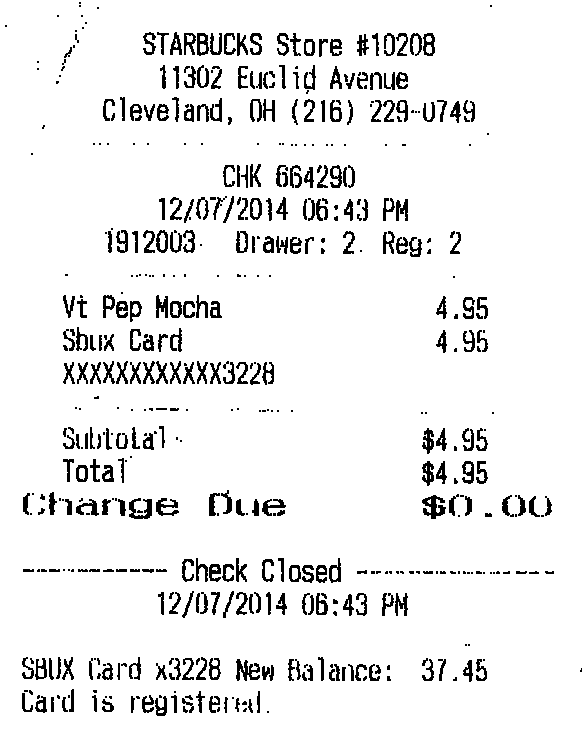

In [7]:
eroded_image = ImageTransformer() \
.addErodeTransform(2,2)\
.setInputCol("image") \
.setOutputCol("eroded_image") \
.transform(image_df)

display_images(eroded_image, "eroded_image")

## Dilation


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 582 px
    Height: 744 px
    Mode: 12
    Number of channels: 3


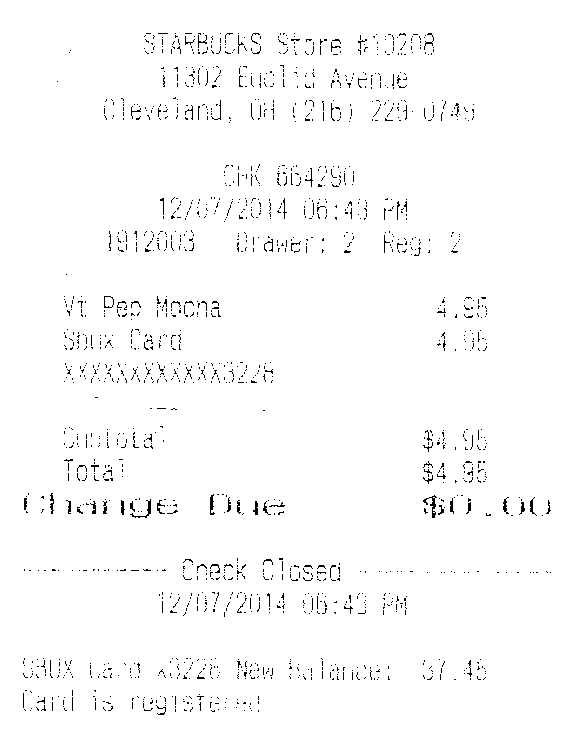

In [8]:
dilated_image = ImageTransformer() \
.addDilateTransform(1, 2)\
.setInputCol("image") \
.setOutputCol("dilated_image") \
.transform(image_df)

display_images(dilated_image, "dilated_image")

## Remove Objects


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 1164 px
    Height: 1488 px
    Mode: 12
    Number of channels: 3


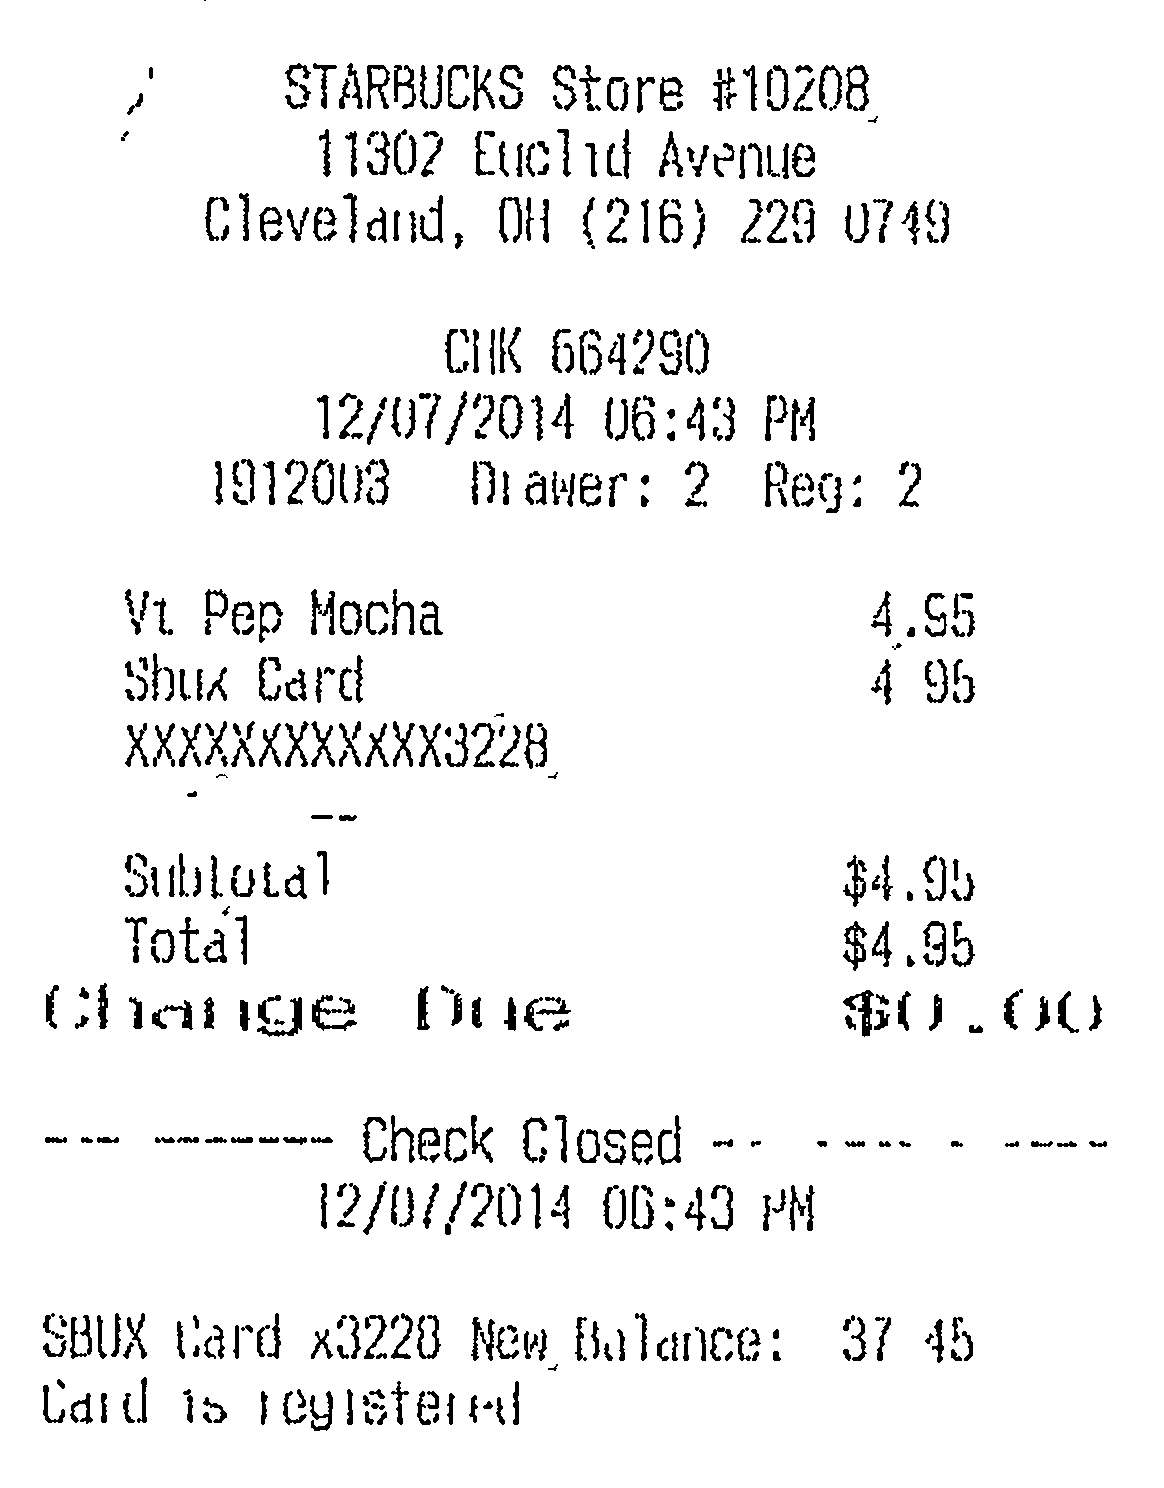

In [9]:
corrected_image = ImageTransformer() \
    .addScalingTransform(2) \
    .addAdaptiveThreshold(31, 2)\
    .addRemoveObjects(10, 500) \
    .setInputCol("image") \
    .setOutputCol("corrected_image") \
    .transform(image_df)

display_images(corrected_image, "corrected_image")

## Median Blur


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 1164 px
    Height: 1488 px
    Mode: 12
    Number of channels: 3


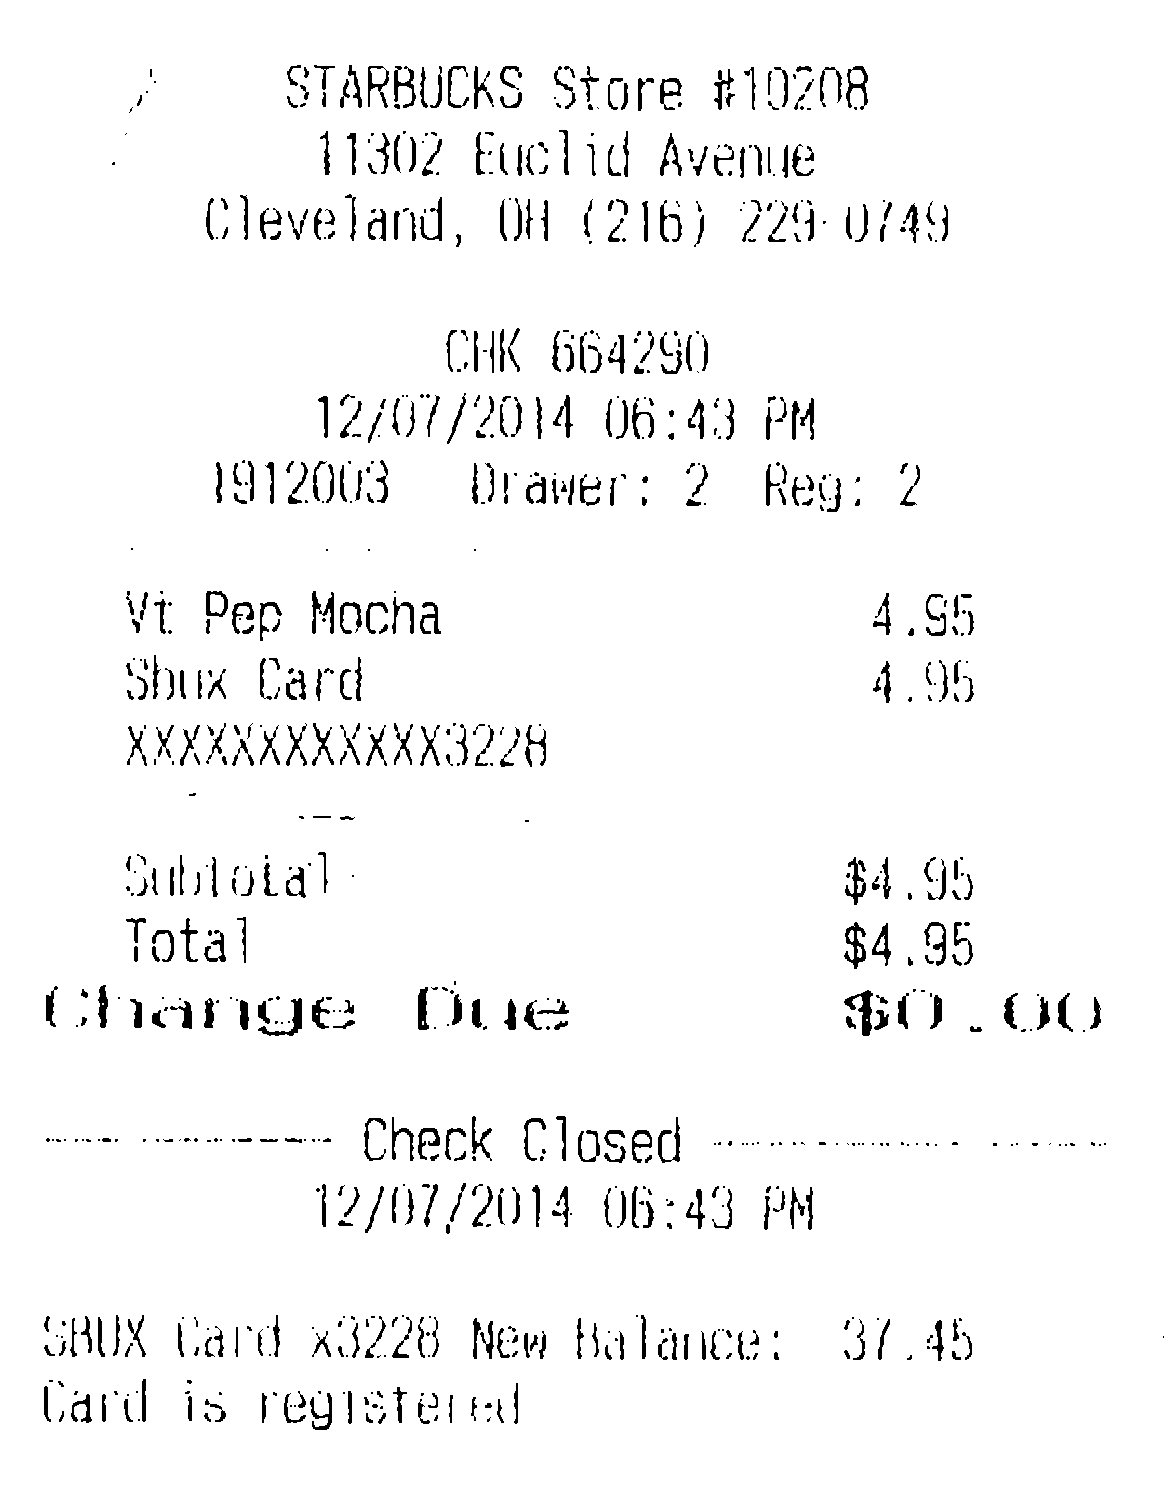

In [10]:
corrected_image = ImageTransformer() \
    .addScalingTransform(2) \
    .addMedianBlur(3) \
    .setInputCol("image") \
    .setOutputCol("corrected_image") \
    .transform(image_df)

display_images(corrected_image, "corrected_image")

## GPU Image transformation


    Image #0:
    Origin: file:/usr/local/lib/python3.12/dist-packages/sparkocr/resources/ocr/images/check.jpg
    Resolution: 199 dpi
    Width: 4656 px
    Height: 5952 px
    Mode: 12
    Number of channels: 3


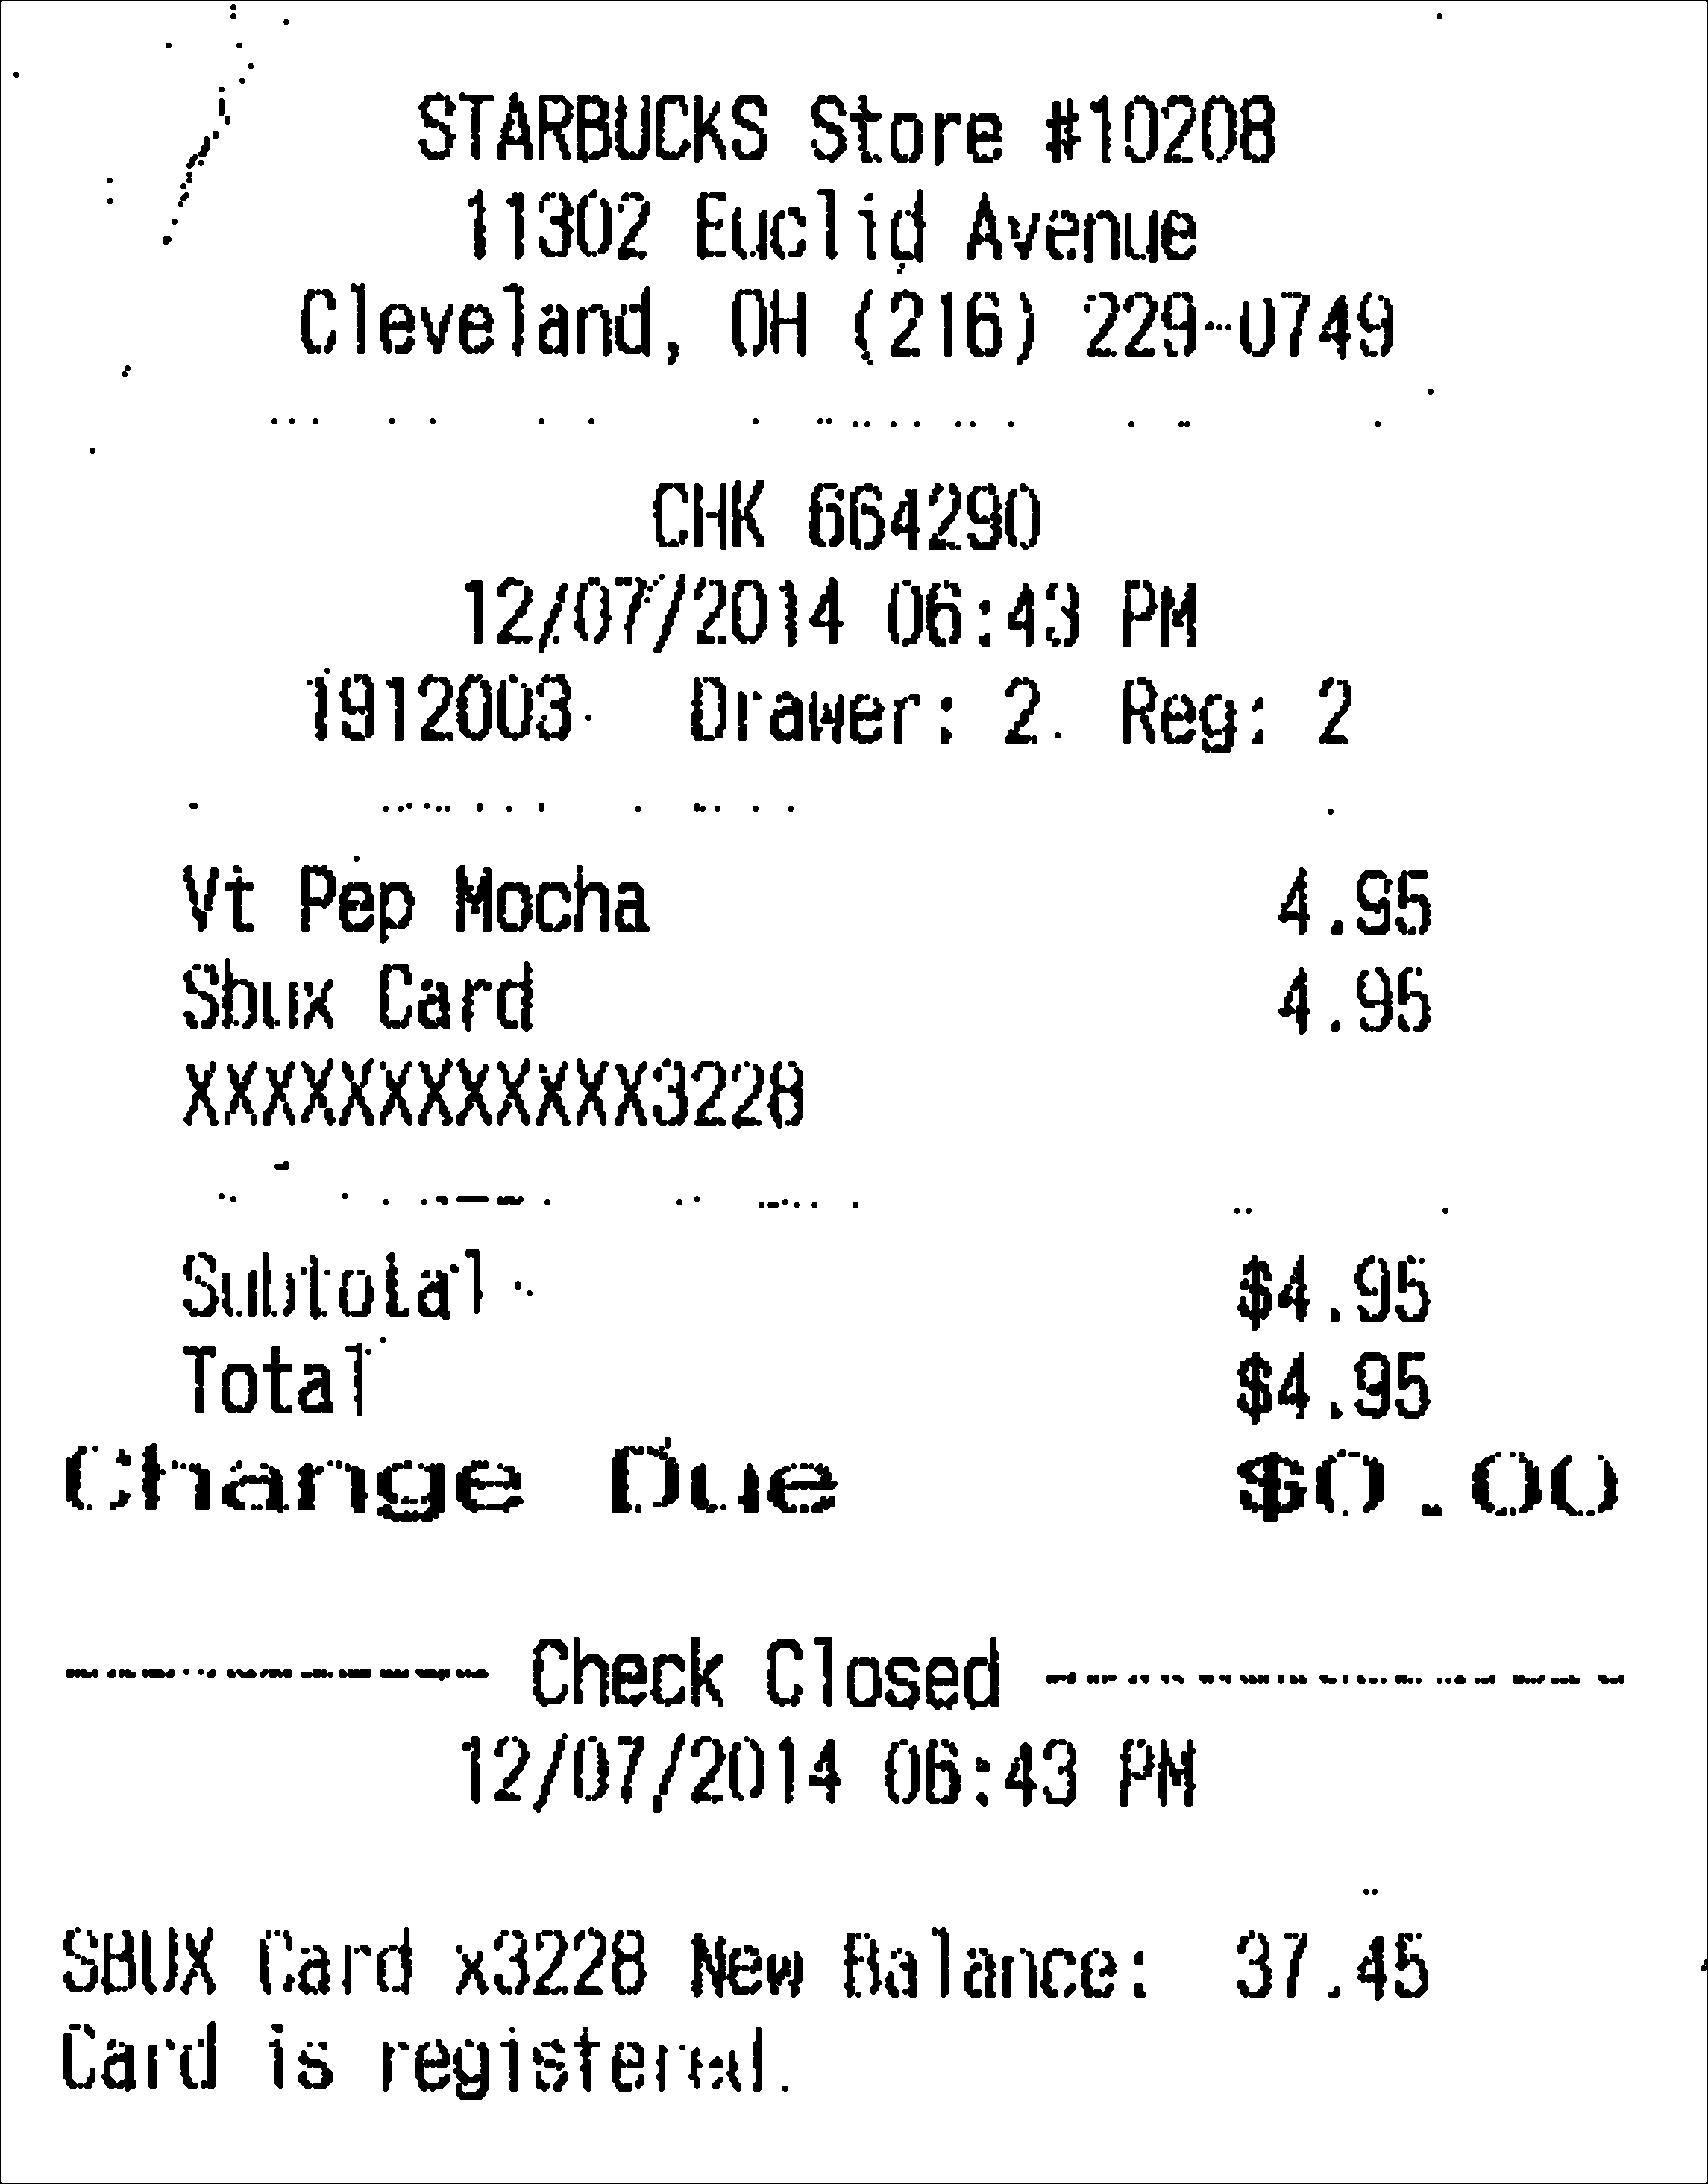

In [11]:
multiple_image = GPUImageTransformer() \
    .addScalingTransform(8) \
    .addOtsuTransform() \
    .addErodeTransform(3, 3) \
    .setInputCol("image") \
    .setOutputCol("multiple_image") \
    .transform(image_df)

display_images(multiple_image, "multiple_image")